### Exercise 6
Nel codice di base dell'esercizio $4$ sono stati implementati il calcolo della suscettività magnetica, del calore specifico e della magnetizzazione. Per ottenere queste proprietà sono state eseguite simulazioni utilizzando sia l'algoritmo di Metropolis sia il Gibbs sampling, mantenendo un campo magnetico esterno pari a $h=0$, ad eccezione del calcolo della magnetizzazione, per il quale è stato utilizzato $h=0.02$. Sono stati ottenuti i seguenti risultati, confrontati con le curve teoriche attese per le quattro proprietà analizzate (è inclusa anche l'energia totale):

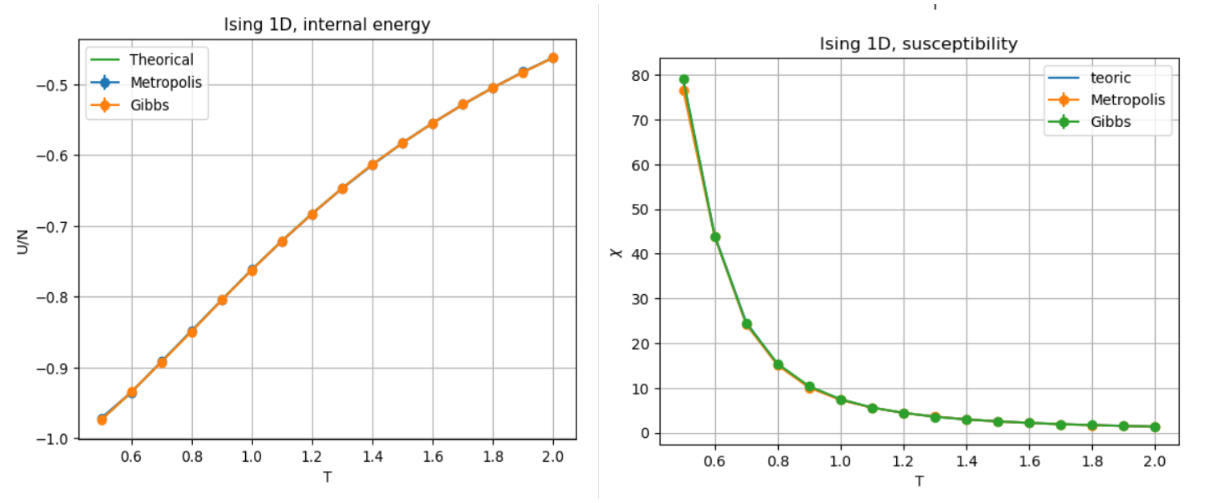

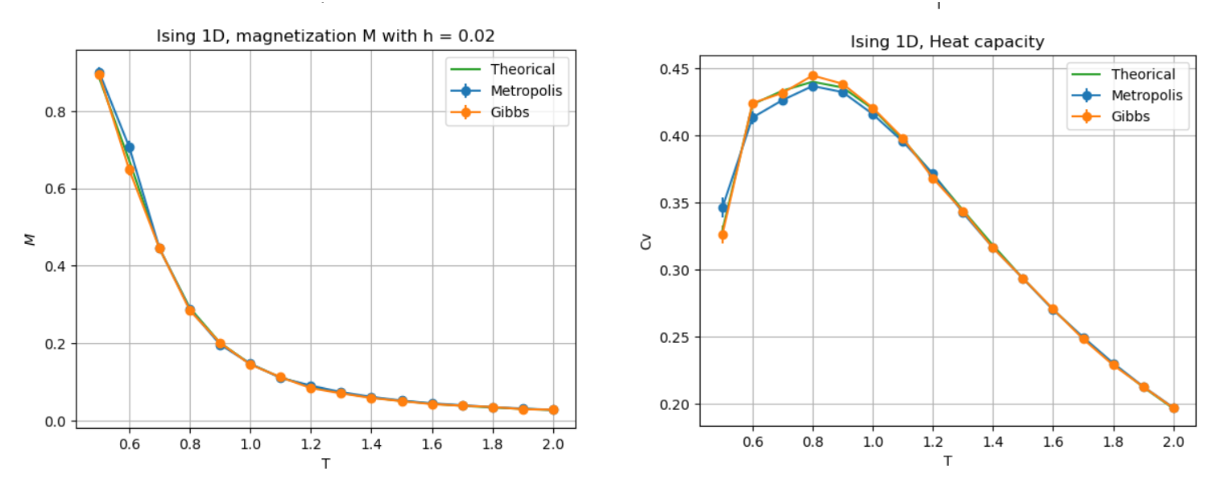

Come si può osservare, i risultati ottenuti con i due algoritmi convergono verso la stessa curva, permettendo di concludere che i metodi di campionamento di Metropolis e di Gibbs sono equivalenti e forniscono risultati coerenti con le previsioni teoriche.

Nota: nel caso particolare della suscettività magnetica, poiché $h=0$, si ha $\langle M \rangle = 0$, il che semplifica il calcolo alla sola varianza della magnetizzazione: $\chi = \beta \langle M^2\rangle$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
points=100
T = np.linspace(0.5, 2.0, 16)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th

# internal energy
e = -J*( th + ch*thN )/( 1 + thN )
e_metro = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\en_metro.txt")
e_gibbs = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\energia.txt")

plt.errorbar(T, e_metro[:,2],yerr=e_metro[:,3], fmt='o-', label='Metropolis')
plt.errorbar(T, e_gibbs[:,2],yerr=e_gibbs[:,3], fmt='o-', label='Gibbs')
plt.plot(T, e, label ='Theorical')
plt.title('Ising 1D, internal energy')
plt.xlabel('T')
plt.ylabel('U/N')
plt.legend()
plt.grid(True)
plt.show()

# susceptibility
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

chi_metro = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\suscp_metro.txt")
chi_gibbs = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\susceptibilidad.txt")

plt.plot(T, X, label = 'teoric')
plt.errorbar(T, chi_metro[:,2],yerr=chi_metro[:,3], fmt='o-', label='Metropolis')
plt.errorbar(T, chi_gibbs[:,2],yerr=chi_gibbs[:,3], fmt='o-', label='Gibbs')
plt.xlabel('T')
plt.ylabel('$\chi$')
plt.title("Ising 1D, susceptibility")
plt.legend()
plt.grid(True)
plt.show()

# Magnetization
h=0.02 #external field
b = beta
l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

magn_metro = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\magn_metro.txt")
magn_gibbs = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\magnetizacion.txt")

plt.errorbar(T, magn_metro[:,2],yerr=magn_metro[:,3], fmt='o-', label='Metropolis')
plt.errorbar(T, magn_gibbs[:,2],yerr=magn_gibbs[:,3], fmt='o-', label='Gibbs')
plt.plot(T, M, label ='Theorical')
plt.title('Ising 1D, magnetization M with h = 0.02')
plt.xlabel('T')
plt.ylabel('$M$')
plt.legend()
plt.grid(True)
plt.show()

# specific heat
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
cv_metro = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\cv_metro.txt")
cv_gibbs = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\6\calor.txt")

plt.errorbar(T, cv_metro[:,2],yerr=cv_metro[:,3], fmt='o-', label='Metropolis')
plt.errorbar(T, cv_gibbs[:,2],yerr=cv_gibbs[:,3], fmt='o-', label='Gibbs')
plt.plot(T, heat, label ='Theorical')
plt.title('Ising 1D, Heat capacity')
plt.xlabel('T')
plt.ylabel('Cv')
plt.legend()
plt.grid(True)
plt.show()